In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE,RFECV
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.impute import SimpleImputer

In [50]:
df= pd.read_csv('horse.csv')

In [51]:
df.head()

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


In [52]:
features= df.drop(columns='outcome',axis=1)
target=df[['outcome']]

In [53]:
num_col= [i for i in features.columns if features[i].dtype!='O']
cat_col=[i for i in features.columns if features[i].dtype=='O']
print(num_col)
print(cat_col)

['hospital_number', 'rectal_temp', 'pulse', 'respiratory_rate', 'nasogastric_reflux_ph', 'packed_cell_volume', 'total_protein', 'abdomo_protein', 'lesion_1', 'lesion_2', 'lesion_3']
['surgery', 'age', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces', 'abdomen', 'abdomo_appearance', 'surgical_lesion', 'cp_data']


In [54]:
features[cat_col]

,surgery,age,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,rectal_exam_feces,abdomen,abdomo_appearance,surgical_lesion,cp_data
0,no,adult,cool,reduced,NaN,more_3_sec,extreme_pain,absent,severe,NaN,NaN,decreased,distend_large,NaN,no,no
1,yes,adult,NaN,NaN,pale_cyanotic,less_3_sec,mild_pain,absent,slight,NaN,NaN,absent,other,cloudy,no,no
2,no,adult,normal,normal,pale_pink,less_3_sec,mild_pain,hypomotile,none,NaN,NaN,normal,normal,NaN,no,yes
3,yes,young,cold,normal,dark_cyanotic,more_3_sec,depressed,absent,severe,none,less_1_liter,decreased,NaN,serosanguious,yes,yes
4,no,adult,NaN,NaN,dark_cyanotic,more_3_sec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,yes,adult,cold,NaN,pale_cyanotic,more_3_sec,depressed,absent,NaN,NaN,NaN,NaN,distend_large,NaN,no,no
295,no,adult,cool,increased,pale_cyanotic,more_3_sec,severe_pain,hypomotile,moderate,significant,none,absent,distend_small,serosanguious,yes,yes
296,yes,adult,cold,reduced,pale_cyanotic,less_3_sec,severe_pain,absent,moderate,slight,none,decreased,distend_large,NaN,yes,no
297,yes,adult,cool,reduced,pale_pink,less_3_sec,mild_pain,hypomotile,moderate,significant,none,absent,distend_small,serosanguious,yes,yes


In [55]:
ordinal= make_pipeline(OrdinalEncoder())

In [56]:
transformer= ColumnTransformer([('ord',ordinal,cat_col)])

In [57]:
df1=pd.DataFrame(transformer.fit_transform(features[cat_col]),columns=transformer.get_feature_names_out())
simple= SimpleImputer(missing_values=np.nan,strategy='most_frequent')
df1=pd.DataFrame(simple.fit_transform(df1),columns=df1.columns)

In [58]:
simple1= SimpleImputer(missing_values=np.nan,strategy='median')
df2= pd.DataFrame(simple1.fit_transform(features[num_col]),columns=num_col)

In [59]:
std_sca= StandardScaler()

In [60]:
df2=pd.DataFrame(std_sca.fit_transform(df2[num_col]),columns=num_col)

In [61]:
df2

,hospital_number,rectal_temp,pulse,respiratory_rate,nasogastric_reflux_ph,packed_cell_volume,total_protein,abdomo_protein,lesion_1,lesion_2,lesion_3
0,-0.364592,0.496498,-0.194771,-0.087726,0.062143,-0.119170,-0.533355,-0.209831,1.415021,-0.139371,-0.057928
1,-0.361509,1.565603,0.604982,-0.588538,0.062143,0.385530,2.380057,-0.461797,-0.268864,-0.139371,-0.057928
2,-0.364440,0.191039,-1.139933,-0.338132,0.062143,-1.330449,-0.598013,-0.209831,-0.677797,-0.139371,-0.057928
3,2.747804,1.412873,3.367763,3.417962,0.062143,0.183650,-0.578996,2.309828,-0.268864,-0.139371,-0.057928
4,-0.364491,-1.336253,1.186620,0.350485,0.062143,2.808088,-0.571389,-0.209831,0.118585,-0.139371,-0.057928
...,...,...,...,...,...,...,...,...,...,...,...
294,-0.362117,0.038310,1.768258,2.541540,0.062143,0.890229,1.619375,-0.209831,-0.084214,-0.139371,-0.057928
295,-0.366161,-1.488983,0.023343,-0.338132,0.062143,-0.220110,-0.567586,0.630055,-0.268864,-0.139371,-0.057928
296,-0.365060,-1.030795,0.023343,0.037477,0.062143,1.394929,-0.594210,-0.209831,-0.084214,-0.139371,-0.057928
297,-0.364258,-2.558088,1.041210,-0.338132,0.062143,0.385530,-0.624637,0.714044,-0.268864,-0.139371,-0.057928


In [62]:
df1

,ord__surgery,ord__age,ord__temp_of_extremities,ord__peripheral_pulse,ord__mucous_membrane,ord__capillary_refill_time,ord__pain,ord__peristalsis,ord__abdominal_distention,ord__nasogastric_tube,ord__nasogastric_reflux,ord__rectal_exam_feces,ord__abdomen,ord__abdomo_appearance,ord__surgical_lesion,ord__cp_data
0,0.0,0.0,1.0,3.0,3.0,2.0,2.0,0.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,1.0,2.0,4.0,1.0,3.0,0.0,3.0,2.0,2.0,0.0,4.0,1.0,0.0,0.0
2,0.0,0.0,2.0,2.0,5.0,1.0,3.0,2.0,1.0,2.0,2.0,3.0,3.0,1.0,0.0,1.0
3,1.0,1.0,0.0,2.0,2.0,2.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,2.0,1.0,1.0
4,0.0,0.0,1.0,2.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,1.0,0.0,0.0,2.0,4.0,2.0,1.0,0.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0
295,0.0,0.0,1.0,1.0,4.0,2.0,4.0,2.0,0.0,1.0,2.0,0.0,1.0,2.0,1.0,1.0
296,1.0,0.0,0.0,3.0,4.0,1.0,4.0,0.0,0.0,2.0,2.0,1.0,0.0,1.0,1.0,0.0
297,1.0,0.0,1.0,3.0,5.0,1.0,3.0,2.0,0.0,1.0,2.0,0.0,1.0,2.0,1.0,1.0


In [64]:
df_new=pd.concat([df1,df2],axis=1)

In [74]:
def outlier_remove_z_score(df,columns):
    thershold= 3
    z_score= stats.zscore(df[columns])
    return df[(abs(z_score)<thershold).all(axis=1)]

In [75]:
import scipy.stats as stats

In [77]:
df3=outlier_remove_z_score(df_new,col)

In [78]:
df3

,ord__surgery,ord__age,ord__temp_of_extremities,ord__peripheral_pulse,ord__mucous_membrane,ord__capillary_refill_time,ord__pain,ord__peristalsis,ord__abdominal_distention,ord__nasogastric_tube,...,rectal_temp,pulse,respiratory_rate,nasogastric_reflux_ph,packed_cell_volume,total_protein,abdomo_protein,lesion_1,lesion_2,lesion_3
0,0.0,0.0,1.0,3.0,3.0,2.0,2.0,0.0,2.0,2.0,...,0.496498,-0.194771,-0.087726,0.062143,-0.119170,-0.533355,-0.209831,1.415021,-0.139371,-0.057928
1,1.0,0.0,1.0,2.0,4.0,1.0,3.0,0.0,3.0,2.0,...,1.565603,0.604982,-0.588538,0.062143,0.385530,2.380057,-0.461797,-0.268864,-0.139371,-0.057928
2,0.0,0.0,2.0,2.0,5.0,1.0,3.0,2.0,1.0,2.0,...,0.191039,-1.139933,-0.338132,0.062143,-1.330449,-0.598013,-0.209831,-0.677797,-0.139371,-0.057928
4,0.0,0.0,1.0,2.0,2.0,2.0,3.0,2.0,1.0,2.0,...,-1.336253,1.186620,0.350485,0.062143,2.808088,-0.571389,-0.209831,0.118585,-0.139371,-0.057928
5,0.0,0.0,3.0,2.0,5.0,1.0,1.0,2.0,3.0,2.0,...,0.038310,-0.267476,-0.275531,0.062143,-0.119170,-0.567586,-0.209831,-0.677797,-0.139371,-0.057928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,1.0,0.0,0.0,2.0,4.0,2.0,1.0,0.0,1.0,2.0,...,0.038310,1.768258,2.541540,0.062143,0.890229,1.619375,-0.209831,-0.084214,-0.139371,-0.057928
295,0.0,0.0,1.0,1.0,4.0,2.0,4.0,2.0,0.0,1.0,...,-1.488983,0.023343,-0.338132,0.062143,-0.220110,-0.567586,0.630055,-0.268864,-0.139371,-0.057928
296,1.0,0.0,0.0,3.0,4.0,1.0,4.0,0.0,0.0,2.0,...,-1.030795,0.023343,0.037477,0.062143,1.394929,-0.594210,-0.209831,-0.084214,-0.139371,-0.057928
297,1.0,0.0,1.0,3.0,5.0,1.0,3.0,2.0,0.0,1.0,...,-2.558088,1.041210,-0.338132,0.062143,0.385530,-0.624637,0.714044,-0.268864,-0.139371,-0.057928


In [79]:
dec_tree= DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=3)

In [86]:
df4=pd.merge(df3,target,left_index=True,right_index=True)

In [87]:
features_new= df4.drop(columns='outcome')
target_new= df4[['outcome']]

In [88]:
x_train,x_test,y_train,y_test= train_test_split(features_new,target_new,train_size=0.75,random_state=100)

In [89]:
dec_tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [90]:
y_pred= dec_tree.predict(x_test)

In [91]:
accuracy_score(y_test,y_pred)

0.6607142857142857

In [100]:
df.outcome.value_counts()

outcome
lived         178
died           77
euthanized     44
Name: count, dtype: int64

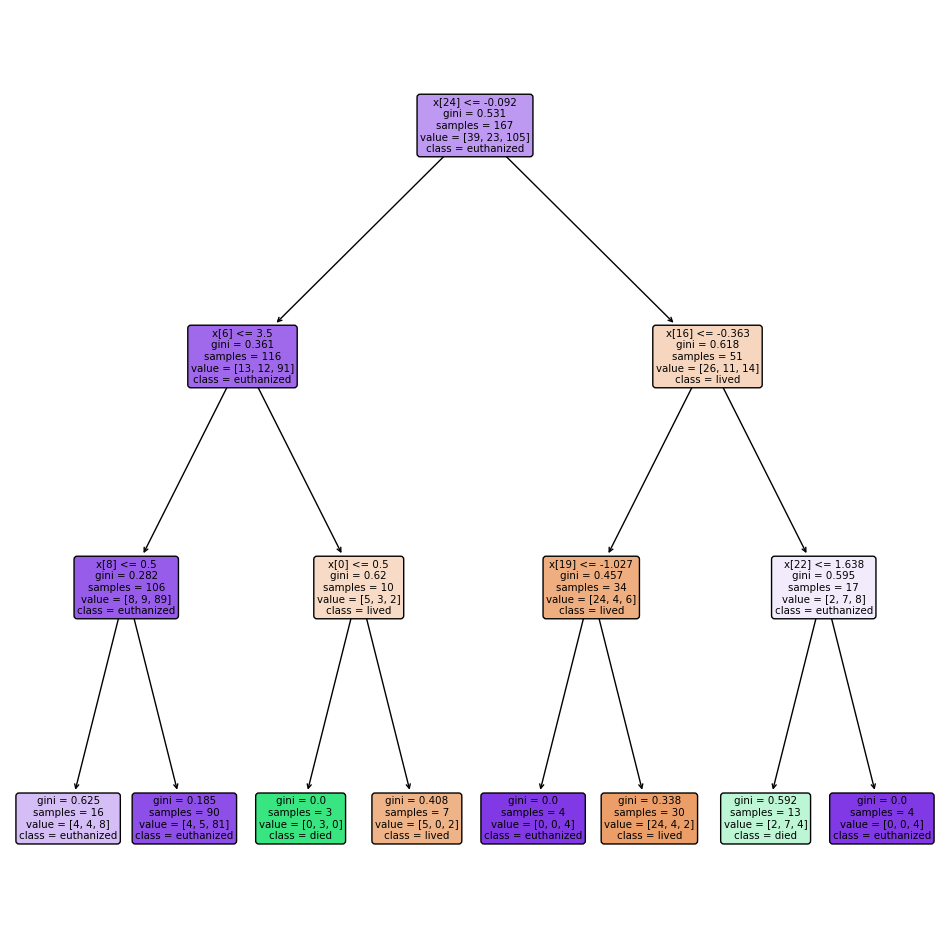

In [101]:
plt.figure(figsize=(12,12))
plot_tree(dec_tree,filled=True,rounded=True,class_names=['lived','died','euthanized']);

In [114]:
rfe= RFE(dec_tree,n_features_to_select=10)

In [115]:
rfe.fit(x_train,y_train)

RFE(estimator=DecisionTreeClassifier(max_depth=3), n_features_to_select=10)

In [116]:
rfe.support_

array([ True, False, False, False, False, False,  True, False,  True,
       False, False, False, False, False, False, False,  True, False,
       False,  True,  True,  True,  True,  True,  True, False, False])

In [117]:
rfe.ranking_

array([ 1,  9,  8,  7,  6,  5,  1,  4,  1, 11, 13, 15, 17, 18, 16, 14,  1,
        3,  2,  1,  1,  1,  1,  1,  1, 10, 12])

In [118]:
mask=rfe.get_support()

In [119]:
a=np.array(features_new.columns)

In [120]:
a[mask]

array(['ord__surgery', 'ord__pain', 'ord__abdominal_distention',
       'hospital_number', 'respiratory_rate', 'nasogastric_reflux_ph',
       'packed_cell_volume', 'total_protein', 'abdomo_protein',
       'lesion_1'], dtype=object)